# Calculate the effective MIZ width of the AltiKa dataset

## Get datastore

In [1]:
from intake import cat
from xarray import DataTree, map_over_datasets
from dask.distributed import Client
import glob
import xarray as xr
import numpy as np
from datetime import timedelta
import cf_xarray as cfxr
import xesmf
import xesmf as xe
import re
import os
import time
import intake
from tqdm.notebook import tqdm

import cftime
import calendar
import cftime
import calendar
import imageio.v2 as imageio
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.lines as mlines
import cartopy.feature as cft

# Import my functions
functions_path = os.path.abspath("/home/566/nd0349/access-om3-analysis/functions")
if functions_path not in sys.path:
    sys.path.append(functions_path)
from get_files import *
from plot_settings import *
from fstd import *
from parameters import *
π = np.pi
test()

Functions from get_files.py imported!


In [2]:
datastore_name = "/scratch/ps29/nd0349/access-om3/archive/WW3-standalone-ERA5-dice-2013/experiment_datastore.json"
# datastore_name = "/scratch/tm70/ek4684/access-om3/archive/Standalone_WW3_ERA5_dice/experiment_datastore.json"


model = Path(datastore_name).parts[-4] # "MCW-ERA5" # 
experiment = Path(datastore_name).parts[-2]
iaf = "ryf" not in experiment

output_frequency = "fx" # "1day" "1mon"
print(model, experiment)

access-om3 WW3-standalone-ERA5-dice-2013


In [3]:
# experiment = experiment + "_ezhil"

In [4]:
figpath = f"/g/data/ps29/nd0349/access-om3-analysis-figs/{experiment}"
os.makedirs(figpath, exist_ok=True)

In [43]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35553 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/35553/status,
Dashboard: /proxy/35553/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45163,Workers: 0
Dashboard: /proxy/35553/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39159,Total threads: 1
Dashboard: /proxy/41935/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:42985,


In [6]:
print(client.dashboard_link)

/proxy/8787/status


## See what data is available

In [7]:
datastore = intake.open_esm_datastore(
    f"{datastore_name}", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)

datastore

,unique
filename,243
file_id,1
path,243
filename_timestamp,243
frequency,1
start_date,243
end_date,243
variable,15
variable_long_name,15
variable_standard_name,1


In [8]:
datastore.unique().frequency
datastore.search(frequency=output_frequency).unique().variable#[0:10]
# esm_datastore.df.frequency.unique()

['mapsta',
 'UAX',
 'UAY',
 'ICE',
 'ICEH',
 'ICEF',
 'HS',
 'T02',
 'T0M1',
 'T01',
 'FP0',
 'THM',
 'EF',
 'USSX',
 'USSY']

In [9]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [10]:
datastore.unique()['variable']

['mapsta',
 'UAX',
 'UAY',
 'ICE',
 'ICEH',
 'ICEF',
 'HS',
 'T02',
 'T0M1',
 'T01',
 'FP0',
 'THM',
 'EF',
 'USSX',
 'USSY']

In [11]:
datastore_filtered = datastore.search(
    variable=["aice_m", "hi_m", "fsdrad_m", "wave_sig_ht_m", "uvel_m", "vvel_m", "uatm_m", "vatm_m"], #frequency=output_frequency, #require_all_on="path"
)
datastore_filtered.unique()
# access-om3.cice.1mon.mean.1984-01.nc

filename                  []
file_id                   []
path                      []
filename_timestamp        []
frequency                 []
start_date                []
end_date                  []
variable                  []
variable_long_name        []
variable_standard_name    []
variable_cell_methods     []
variable_units            []
realm                     []
derived_variable          []
dtype: object

In [12]:
# datastore_filtered = datastore.search(
#     variable=["TLON", "TLAT"], #frequency=output_frequency, #require_all_on="path"
# )
# datastore_filtered.unique()

## Load in WW3 data

In [13]:
xarray_open_kwargs = {"chunks": {"time": 12, "nx": -1, "ny": -1}}
ds_ww3 = datastore.search(variable=["EF", "HS", "ICE", "ICEF", "ICEH", "THM", "FP0", "UAX", "UAY"], require_all_on="path").to_dask(xarray_open_kwargs=xarray_open_kwargs)
files = datastore.search(variable=["EF", "HS", "ICE", "ICEF", "ICEH", "THM", "FP0", "UAX", "UAY"], require_all_on="path").unique().filename

import re
clean_dates = [re.search(r"\d{4}-\d{2}-\d{2}", f).group() for f in files]
tmp_dates = pd.to_datetime(clean_dates)

grid_ds = xr.open_dataset('/g/data/vk83/configurations/inputs/access-om3/cice/grids/global.1deg/2024.05.14/grid.nc')
ds_ww3.coords['TLON'] = np.degrees(grid_ds['tlon'])
ds_ww3.coords['TLAT'] = np.degrees(grid_ds['tlat'])
ds_ww3['tarea'] = grid_ds['tarea']
ds_ww3['HTE'] = grid_ds['hte']/100 # cm to m
ds_ww3 = ds_ww3.rename({"ni": "nx", "nj": "ny"})

# coords = datastore.search(variable=["geolat", "geolon"]).to_dask().compute()
# coords = coords.fillna(0.0)
# ds_ww3 = ds_ww3.assign_coords(coords)
ds_ww3

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 243, ny: 300, nx: 360, freq: 25)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2013-01-02 2013-01-03 ... 2013-09-01
    ulat     (ny, nx) float64 864kB ...
    ulon     (ny, nx) float64 864kB ...
    tlat     (ny, nx) float64 864kB -1.359 -1.359 -1.359 ... 1.153 1.145 1.138
    tlon     (ny, nx) float64 864kB -4.878 -4.861 -4.843 ... 1.395 1.396 1.396
    TLON     (ny, nx) float64 864kB -279.5 -278.5 -277.5 ... 79.96 79.97 79.99
    TLAT     (ny, nx) float64 864kB -77.88 -77.88 -77.88 ... 66.04 65.63 65.21
Dimensions without coordinates: ny, nx, freq
Data variables:
    UAY      (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAX      (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    EF       (time, freq, ny, nx) float32 3GB dask.array<chunksize=(1, 25, 300, 360), meta=np.ndarray>
    HS       (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ICE      (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    THM      (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ICEH     (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    FP0      (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ICEF     (time, ny, nx) float32 105MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    tarea    (ny, nx) float64 864kB ...
    HTE      (ny, nx) float64 864kB 2.745e+04 2.745e+04 ... 1.641e+03 5.85e-12
Attributes:
    intake_esm_vars:                          ['UAY', 'UAX', 'EF', 'HS', 'ICE...
    intake_esm_attrs:file_id:                 access_om3_ww3_hi_XXXX_XX_XX_XXXXX
    intake_esm_attrs:frequency:               fx
    intake_esm_attrs:variable:                mapsta,UAX,UAY,ICE,ICEH,ICEF,HS...
    intake_esm_attrs:variable_long_name:      map status,Mean wind, x-compone...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,,,,,,,
    intake_esm_attrs:variable_units:          unitless,m s-1,m s-1,nd,m,m,m,s...
    intake_esm_attrs:realm:                   wave
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   access_om3_ww3_hi_XXXX_XX_XX_XX...

## Compare with Fraser et al. (2026)

In [14]:
def ReadInAltika(version, year=2019):
    if version == '0.6':
        month_range = range(1,13)
        df = pd.concat((pd.read_csv('/g/data/ps29/nd0349/Fraser-2024/data/v0_15/' + str(year) + ("%02d" % (month,)) + '_output_v0_6.csv') 
                        for month in tqdm(month_range, total = len(month_range), desc = "Reading in Alex's data")),
                        ignore_index=True)
        
        df = df[['first_meas_time', 'swhAtMyEdge', 'lonAtMyEdge', 'latAtMyEdge', 'lonAtAltiKaEdge','latAtAltiKaEdge', 'lonAtInnerMIZ', 'latAtInnerMIZ', 'mizWidthAlongTrackFromMyEdge', 'mizWidthAlongTrackFromAltikaEdge']]
        
    
    elif version == '0.10':
        # Version 0.10
        df_raw = pd.read_csv('data/v0_10/' + str(year) + '_all_output_v0_10.csv')
        row_temp = df_raw.loc[0,:]
        row_temp.values
        # Fill the first row with temporary data
        df = pd.DataFrame([row_temp], columns = df_raw.columns)
        
        numberRows,NumberCols = df_raw.shape
        
        for i in range(numberRows):
            row_temp = df_raw.loc[i,:]
            row = pd.DataFrame([row_temp], columns = df_raw.columns)
            if  (row['too_many_switches_flag'].values == 0) & (row['hit_continent_flag'].values == 0) & (row['ice_edge_diff_flag'].values == 0) & (row['latAtInnerMIZ'].values < row['latAtAltiKaEdge'].values) & (row['latAtInnerMIZ'].values < row['latAtMyEdge'].values) & (np.abs(row['lonAtInnerMIZ'].values - row['lonAtAltiKaEdge'].values) < 10):
                df = pd.concat([df,row])
        df.drop([0])
        df = df[['first_meas_time', 'swhAtMyEdge', 'lonAtMyEdge', 'latAtMyEdge', 'lonAtAltiKaEdge','latAtAltiKaEdge', 'lonAtInnerMIZ', 'latAtInnerMIZ', 'mizWidthAlongTrackFromMyEdge', 'mizWidthAlongTrackFromAltikaEdge']]
    elif version == '0.11':
        # Version 0.11
        df_raw = pd.read_csv('data/v0_11/' + str(year) + '_all_output_v0_11.csv')
        row_temp = df_raw.loc[0,:]
        row_temp.values
        # Fill the first row with temporary data
        df = pd.DataFrame([row_temp], columns = df_raw.columns)
        
        numberRows,NumberCols = df_raw.shape
        
        for i in range(numberRows):
            row_temp = df_raw.loc[i,:]
            row = pd.DataFrame([row_temp], columns = df_raw.columns)
            if  (row['too_many_switches_flag'].values == 0) & (row['hit_continent_flag'].values == 0) & (row['ice_edge_diff_flag'].values == 0) & (row['latAtInnerMIZ'].values < row['latAtAltiKaEdge'].values) & (row['latAtInnerMIZ'].values < row['latAtMyEdge'].values) & (np.abs(row['lonAtInnerMIZ'].values - row['lonAtAltiKaEdge'].values) < 10):
                df = pd.concat([df,row])
        df.drop([0])
        df = df[['first_meas_time', 'swhAtMyEdge', 'lonAtMyEdge', 'latAtMyEdge', 'lonAtAltiKaEdge','latAtAltiKaEdge', 'lonAtInnerMIZ', 'latAtInnerMIZ', 'mizWidthAlongTrackFromMyEdge', 'mizWidthAlongTrackFromAltikaEdge']]
    elif version == '0.12':
        # Version 0.12
        df_raw = pd.read_csv('data/v0_12/' + str(year) + '_all_output_v0_12.csv')
        row_temp = df_raw.loc[0,:]
        row_temp.values
        # Fill the first row with temporary data
        df = pd.DataFrame([row_temp], columns = df_raw.columns)
        
        numberRows,NumberCols = df_raw.shape
        
        for i in range(numberRows):
            row_temp = df_raw.loc[i,:]
            row = pd.DataFrame([row_temp], columns = df_raw.columns)
            if  (row['too_many_switches_flag'].values == 0) & (row['hit_continent_flag'].values == 0) & (row['ice_edge_diff_flag'].values == 0) & (row['latAtInnerMIZ'].values < row['latAtAltiKaEdge'].values) & (row['latAtInnerMIZ'].values < row['latAtMyEdge'].values) & (np.abs(row['lonAtInnerMIZ'].values - row['lonAtAltiKaEdge'].values) < 10):
                df = pd.concat([df,row])
        df.drop([0])
        df = df[['first_meas_time', 'swhAtMyEdge', 'lonAtMyEdge', 'latAtMyEdge', 'lonAtAltiKaEdge','latAtAltiKaEdge', 'lonAtInnerMIZ', 'latAtInnerMIZ', 'mizWidthAlongTrackFromMyEdge', 'mizWidthAlongTrackFromAltikaEdge']]
        
    elif version == '0.15':
        # Version 0.15
        df_raw = pd.read_csv('/g/data/ps29/nd0349/Fraser-2024/data/v0_15/' + str(year) + '_all_output_v0_15.csv')
        row_temp = df_raw.loc[0,:]
        row_temp.values
        # Fill the first row with temporary data
        df = pd.DataFrame([row_temp], columns = df_raw.columns)
        
        numberRows,NumberCols = df_raw.shape
        
        for i in range(numberRows):
            row_temp = df_raw.loc[i,:]
            row = pd.DataFrame([row_temp], columns = df_raw.columns)
            if  (row['too_many_switches_flag'].values == 0) & (row['hit_continent_flag'].values == 0) & (row['ice_edge_diff_flag'].values == 0) & (row['latAtInnerMIZ'].values < row['latAtAltiKaEdge'].values) & (row['latAtInnerMIZ'].values < row['latAtMyEdge'].values) & (np.abs(row['lonAtInnerMIZ'].values - row['lonAtAltiKaEdge'].values) < 10):
                df = pd.concat([df,row])
        df.drop([0])
        
    # Add dates to dataframe
    df['date'] = pd.to_datetime(df["first_meas_time"])#, format='%Y-%m-%d').dt.round("d")
    df['day'] = pd.to_datetime(df['date']).dt.day
    df['year'] = pd.to_datetime(df['date']).dt.year
    df['month'] = pd.to_datetime(df['date']).dt.month
    return df

In [15]:
from tqdm.notebook import tqdm

years = range(2013, 2024)
dfs = []

# swh_min = 10**-12
# swh_max = 100
# miz_max = 10000
# miz_min = -10**-12

for year in tqdm(years):
    # print(year)
    df = pd.DataFrame(ReadInAltika(version='0.15', year=year))
    df = df[['first_meas_time', 'swhAtMyEdge', 'lonAtMyEdge', 'latAtMyEdge', 'lonAtAltiKaEdge','latAtAltiKaEdge', 'lonAtInnerMIZ', 'latAtInnerMIZ', 'mizWidthAlongTrackFromMyEdge', 'mizWidthAlongTrackFromAltikaEdge']]
    df['date'] = pd.to_datetime(df["first_meas_time"]).dt.date # , format='%Y-%m-%d %H:%M:%S.%f').dt.date
    df['day'] = pd.to_datetime(df['date']).dt.day
    df['year'] = pd.to_datetime(df['date']).dt.year
    df['month'] = pd.to_datetime(df['date']).dt.month
    df['mizwidth_lat'] = abs(df['latAtAltiKaEdge'] - df['latAtInnerMIZ'])*111.32 # Alex's conversion from latitudes to km

    dfs.append(df)
# Combine into one dataframe
df_all = pd.concat(dfs, ignore_index=True)
# df_tmp = df_all.copy()
# condition_met_df = (df_tmp['swhAtMyEdge'] < swh_max) & (df_tmp['swhAtMyEdge'] > swh_min) & (df_tmp['mizWidthAlongTrackFromAltikaEdge'] < miz_max) & (df_tmp['mizWidthAlongTrackFromAltikaEdge'] > miz_min)
# df_all = df_tmp.where(condition_met_df)
df_all.head()

  0%|          | 0/11 [00:00<?, ?it/s]

,first_meas_time,swhAtMyEdge,lonAtMyEdge,latAtMyEdge,lonAtAltiKaEdge,latAtAltiKaEdge,lonAtInnerMIZ,latAtInnerMIZ,mizWidthAlongTrackFromMyEdge,mizWidthAlongTrackFromAltikaEdge,date,day,year,month,mizwidth_lat
0,2013-03-14 06:29:45.868806,1.687726,144.227909,-65.075224,143.941111,-65.370226,143.705466,-65.611763,64.580466,29.058073,2013-03-14,14,2013,3,26.887899
1,2013-03-14 06:29:45.868806,1.687726,144.227909,-65.075224,143.941111,-65.370226,143.705466,-65.611763,64.580466,29.058073,2013-03-14,14,2013,3,26.887899
2,2013-03-14 07:20:03.662676,1.903122,1.938063,-68.331988,2.380483,-68.678470,3.743463,-69.687394,167.533329,124.858594,2013-03-14,14,2013,3,112.313420
3,2013-03-14 08:10:21.720821,2.011015,119.110686,-65.043592,118.766595,-65.397606,118.733795,-65.434442,47.005832,4.380543,2013-03-14,14,2013,3,4.100584
4,2013-03-14 09:00:39.517474,1.635128,339.407504,-70.235543,340.841359,-71.139443,341.304206,-71.418344,149.157700,35.263525,2013-03-14,14,2013,3,31.047259


In [16]:
month = 9
year = 2019

In [17]:
df_all["time"] = pd.to_datetime(df_all["first_meas_time"])
df_month = df_all[
    (df_all["time"].dt.year == year) &
    (df_all["time"].dt.month == month)
].copy()
df_month.head()

,first_meas_time,swhAtMyEdge,lonAtMyEdge,latAtMyEdge,lonAtAltiKaEdge,latAtAltiKaEdge,lonAtInnerMIZ,latAtInnerMIZ,mizWidthAlongTrackFromMyEdge,mizWidthAlongTrackFromAltikaEdge,date,day,year,month,mizwidth_lat,time
52046,2019-09-01 00:26:31.891037,7.119052,231.718804,-66.206593,231.657039,-66.265351,228.923165,-68.608244,293.392127,286.275206,2019-09-01,1,2019,9,260.810849,2019-09-01 00:26:31.891037
52047,2019-09-01 01:16:50.559968,2.726842,81.809816,-58.337262,82.002250,-58.639462,83.986592,-61.490262,371.736399,336.253792,2019-09-01,1,2019,9,317.351056,2019-09-01 01:16:50.559968
52048,2019-09-01 02:07:08.880244,4.217586,209.162129,-63.465617,208.693659,-64.001099,207.481092,-65.298769,219.861795,155.841700,2019-09-01,1,2019,9,144.456624,2019-09-01 02:07:08.880244
52049,2019-09-01 02:57:27.524435,3.009857,58.106820,-60.496565,58.279247,-60.737032,59.400887,-62.222530,204.401610,175.993285,2019-09-01,1,2019,9,165.365637,2019-09-01 02:57:27.524435
52050,2019-09-01 03:47:45.835492,2.422874,183.284259,-64.280474,182.901129,-64.695636,181.900249,-65.725236,173.797016,123.982544,2019-09-01,1,2019,9,114.615072,2019-09-01 03:47:45.835492


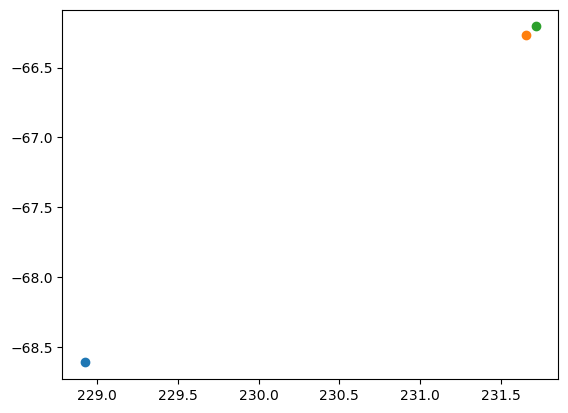

In [18]:
df_example = df_month.iloc[0].copy()
plt.scatter(df_example['lonAtInnerMIZ'], df_example['latAtInnerMIZ'])
plt.scatter(df_example['lonAtAltiKaEdge'], df_example['latAtAltiKaEdge'])
plt.scatter(df_example['lonAtMyEdge'], df_example['latAtMyEdge'])

In [19]:
def haversine_km(lon1, lat1, lon2, lat2, radius=6371.0):
    lon1 = np.deg2rad(lon1)
    lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2)
    lat2 = np.deg2rad(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return radius * c


In [22]:
df_example = df_month.iloc[0].copy()

dist_altika_to_inner = haversine_km(
    df_example["lonAtAltiKaEdge"],
    df_example["latAtAltiKaEdge"],
    df_example["lonAtInnerMIZ"],
    df_example["latAtInnerMIZ"]
)

dist_myedge_to_inner = haversine_km(
    df_example["lonAtMyEdge"],
    df_example["latAtMyEdge"],
    df_example["lonAtInnerMIZ"],
    df_example["latAtInnerMIZ"]
)

dist_myedge_to_altika = haversine_km(
    df_example["lonAtMyEdge"],
    df_example["latAtMyEdge"],
    df_example["lonAtAltiKaEdge"],
    df_example["latAtAltiKaEdge"]
)

print("AltiKa edge to inner MIZ:", dist_altika_to_inner, "km")
print("MyEdge to inner MIZ:", dist_myedge_to_inner, "km")
print("MyEdge to AltiKa edge:", dist_myedge_to_altika, "km")
print("AltiKa MIZ:", df_example["mizWidthAlongTrackFromAltikaEdge"], "km")
print("MyEdge MIZ:", df_example["mizWidthAlongTrackFromMyEdge"], "km")


AltiKa edge to inner MIZ: 285.3734903368056 km
MyEdge to inner MIZ: 292.4690659885921 km
MyEdge to AltiKa edge: 7.095591587492043 km
AltiKa MIZ: 286.27520565662485 km
MyEdge MIZ: 293.39212747502575 km


In [36]:
df_month["altika_myedge_dist_km"] = haversine_km(
    df_month["lonAtAltiKaEdge"],
    df_month["latAtAltiKaEdge"],
    df_month["lonAtMyEdge"],
    df_month["latAtMyEdge"]
)

df_month_filtered = df_month[df_month["altika_myedge_dist_km"] < 50].copy()
print(len(df_month), len(df_month_filtered))
df_month_filtered = df_month_filtered[df_month_filtered["mizWidthAlongTrackFromAltikaEdge"] < 500].copy()
print(len(df_month), len(df_month_filtered))

743 541
743 528


In [41]:
df_month_sample = df_month_filtered.iloc[0:5]

### Read in ERA5 file

In [32]:
month = 9
year = 2019

era5_files = sorted(glob(
    f"/g/data/rt52/era5/single-levels/reanalysis/ci/{year}/ci_era5_oper_sfc_{year}{month:02d}*.nc"
))

print(era5_files)

era5_file = era5_files[0]

ds_era5 = xr.open_dataset(era5_file, engine="netcdf4")
ds_era5

['/g/data/rt52/era5/single-levels/reanalysis/ci/2019/ci_era5_oper_sfc_20190901-20190930.nc']


<xarray.Dataset> Size: 6GB
Dimensions:    (longitude: 1440, latitude: 721, time: 720)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 6kB 2019-09-01 ... 2019-09-30T23:00:00
Data variables:
    siconc     (time, latitude, longitude) float64 6GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-10-09 15:41:56 UTC+1100 by era5_replication_tools-1.2....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis sea_ice_cover 20190901-20190930

In [42]:
# Example: daily or monthly mean ERA5 sea ice concentration
era5_ice_plot = ds_era5["siconc"].isel(time=0)

fig, ax = plt.subplots(
    figsize=(9, 7),
    subplot_kw={"projection": ccrs.SouthPolarStereo()}
)

era5_ice_plot.plot(
    ax=ax,
    x="longitude",
    y="latitude",
    transform=ccrs.PlateCarree(),
    cmap=cmo.ice,
    vmin=0,
    vmax=1,
    add_colorbar=True
)

ax.coastlines()
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

# Plot filtered df tracks
for _, row in df_month_sample.iterrows():
    ax.plot(
        [row["lonAtAltiKaEdge"], row["lonAtInnerMIZ"]],
        [row["latAtAltiKaEdge"], row["latAtInnerMIZ"]],
        color="yellow",
        linewidth=0.8,
        alpha=0.8,
        transform=ccrs.PlateCarree()
    )

# Optional: plot edge points
ax.scatter(
    df_month_sample["lonAtAltiKaEdge"],
    df_month_sample["latAtAltiKaEdge"],
    s=8,
    color="k",
    transform=ccrs.PlateCarree(),
    label="AltiKa edge"
)

ax.scatter(
    df_month_sample["lonAtInnerMIZ"],
    df_month_sample["latAtInnerMIZ"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree(),
    label="Inner MIZ"
)

ax.legend()
plt.show()

2026-05-15 15:25:02,896 - distributed.worker - ERROR - 
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/compatibility.py", line 204, in asyncio_run
    return runner.run(main)
           ^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/asyncio/base_events.py", line 641, in run_until_complete
    self.run_forever()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
    self._run_once()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/asyncio/base_events.py", line 1898, in _run_once
    event_list = self._selector.select(timeout)
        

KeyboardInterrupt: 

2026-05-15 15:25:04,175 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,177 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,180 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,182 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,197 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,206 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,208 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,209 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15 15:25:04,211 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-05-15

## Calculate the effective MIZ width

In [44]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

# Monthly mean ERA5 sea ice concentration
siconc_month = ds_era5["siconc"].mean("time")

# ERA5 grid
era_lats = siconc_month["latitude"].values
era_lons = siconc_month["longitude"].values
era_vals = siconc_month.values

# RegularGridInterpolator wants coordinates increasing
if era_lats[0] > era_lats[-1]:
    era_lats = era_lats[::-1]
    era_vals = era_vals[::-1, :]

siconc_interp = RegularGridInterpolator(
    (era_lats, era_lons),
    era_vals,
    bounds_error=False,
    fill_value=np.nan
)

def lon_to_180(lon):
    return ((lon + 180) % 360) - 180

def mean_siconc_along_track(row, start="altika", n_points=50):
    if start == "altika":
        lon0 = row["lonAtAltiKaEdge"]
        lat0 = row["latAtAltiKaEdge"]
    elif start == "myedge":
        lon0 = row["lonAtMyEdge"]
        lat0 = row["latAtMyEdge"]
    else:
        raise ValueError("start must be 'altika' or 'myedge'")

    lon1 = row["lonAtInnerMIZ"]
    lat1 = row["latAtInnerMIZ"]

    lon0 = lon_to_180(lon0)
    lon1 = lon_to_180(lon1)

    # Handle dateline crossing
    if abs(lon1 - lon0) > 180:
        if lon0 > lon1:
            lon1 += 360
        else:
            lon0 += 360

    track_lons = np.linspace(lon0, lon1, n_points)
    track_lats = np.linspace(lat0, lat1, n_points)

    track_lons = lon_to_180(track_lons)

    points = np.column_stack([track_lats, track_lons])
    siconc_track = siconc_interp(points)

    return np.nanmean(siconc_track)


In [48]:
df_month_filtered = df_month_filtered.copy()
df_month_sample = df_month_filtered#.iloc[0:5]
df_month_sample

,first_meas_time,swhAtMyEdge,lonAtMyEdge,latAtMyEdge,lonAtAltiKaEdge,latAtAltiKaEdge,lonAtInnerMIZ,latAtInnerMIZ,mizWidthAlongTrackFromMyEdge,mizWidthAlongTrackFromAltikaEdge,...,day,year,month,mizwidth_lat,time,altika_myedge_dist_km,mean_siconc_altika_track,mean_siconc_myedge_track,mizWidthAlongTrackFromAltikaEdge_eff_era5,mizWidthAlongTrackFromMyEdge_eff_era5
52046,2019-09-01 00:26:31.891037,7.119052,231.718804,-66.206593,231.657039,-66.265351,228.923165,-68.608244,293.392127,286.275206,...,1,2019,9,260.810849,2019-09-01 00:26:31.891037,7.095592,0.828502,0.823057,237.179622,241.478413
52047,2019-09-01 01:16:50.559968,2.726842,81.809816,-58.337262,82.002250,-58.639462,83.986592,-61.490262,371.736399,336.253792,...,1,2019,9,317.351056,2019-09-01 01:16:50.559968,35.415346,0.739697,0.678598,248.725847,252.259412
52049,2019-09-01 02:57:27.524435,3.009857,58.106820,-60.496565,58.279247,-60.737032,59.400887,-62.222530,204.401610,175.993285,...,1,2019,9,165.365637,2019-09-01 02:57:27.524435,28.345240,0.834706,0.816858,146.902738,166.967170
52050,2019-09-01 03:47:45.835492,2.422874,183.284259,-64.280474,182.901129,-64.695636,181.900249,-65.725236,173.797016,123.982544,...,1,2019,9,114.615072,2019-09-01 03:47:45.835492,49.676540,0.738614,0.614661,91.575246,106.826214
52052,2019-09-01 05:28:22.952726,4.523932,160.634394,-61.232562,160.499693,-61.412622,159.008476,-63.280463,243.350979,222.028623,...,1,2019,9,207.928060,2019-09-01 05:28:22.952726,21.272805,0.563148,0.523377,125.034993,127.364255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52784,2019-09-30 20:29:21.204715,1.784699,294.369227,-62.517884,294.175150,-62.756714,292.706243,-64.448767,230.617788,202.197837,...,30,2019,9,188.359340,2019-09-30 20:29:21.204715,28.348524,0.619539,0.589333,125.269358,135.910693
52785,2019-09-30 21:19:39.761436,3.409903,142.974381,-61.109438,143.152812,-61.349327,144.829661,-63.441622,277.171062,248.773245,...,30,2019,9,232.914279,2019-09-30 21:19:39.761436,28.332220,0.585214,0.532311,145.585468,147.541249
52786,2019-09-30 22:09:58.130696,2.493548,264.849164,-67.105168,264.515332,-67.396791,262.033264,-69.355384,276.678958,241.105896,...,30,2019,9,218.030573,2019-09-30 22:09:58.130696,35.461915,0.673961,0.617863,162.495963,170.949725
52787,2019-09-30 23:00:16.682940,2.627587,118.290295,-61.739215,118.522112,-62.038512,120.109724,-63.944499,262.669989,227.157285,...,30,2019,9,212.174473,2019-09-30 23:00:16.682940,35.427266,0.747696,0.730505,169.844659,191.881869


In [51]:


df_month_filtered["mean_siconc_altika_track"] = df_month_filtered.apply(
    mean_siconc_along_track,
    axis=1,
    start="altika"
)

df_month_filtered["mean_siconc_myedge_track"] = df_month_filtered.apply(
    mean_siconc_along_track,
    axis=1,
    start="myedge"
)

df_month_filtered["mizWidthAlongTrackFromAltikaEdge_eff_era5"] = (
    df_month_filtered["mizWidthAlongTrackFromAltikaEdge"] *
    df_month_filtered["mean_siconc_altika_track"]
)

df_month_filtered["mizWidthAlongTrackFromMyEdge_eff_era5"] = (
    df_month_filtered["mizWidthAlongTrackFromMyEdge"] *
    df_month_filtered["mean_siconc_myedge_track"]
)


In [52]:
df_month_filtered[
    [
        "mizWidthAlongTrackFromAltikaEdge",
        "mean_siconc_altika_track",
        "mizWidthAlongTrackFromAltikaEdge_eff_era5",
    ]
].head()


,mizWidthAlongTrackFromAltikaEdge,mean_siconc_altika_track,mizWidthAlongTrackFromAltikaEdge_eff_era5
52046,286.275206,0.828502,237.179622
52047,336.253792,0.739697,248.725847
52049,175.993285,0.834706,146.902738
52050,123.982544,0.738614,91.575246
52052,222.028623,0.563148,125.034993


In [53]:
df_month_filtered

,first_meas_time,swhAtMyEdge,lonAtMyEdge,latAtMyEdge,lonAtAltiKaEdge,latAtAltiKaEdge,lonAtInnerMIZ,latAtInnerMIZ,mizWidthAlongTrackFromMyEdge,mizWidthAlongTrackFromAltikaEdge,...,day,year,month,mizwidth_lat,time,altika_myedge_dist_km,mean_siconc_altika_track,mean_siconc_myedge_track,mizWidthAlongTrackFromAltikaEdge_eff_era5,mizWidthAlongTrackFromMyEdge_eff_era5
52046,2019-09-01 00:26:31.891037,7.119052,231.718804,-66.206593,231.657039,-66.265351,228.923165,-68.608244,293.392127,286.275206,...,1,2019,9,260.810849,2019-09-01 00:26:31.891037,7.095592,0.828502,0.823057,237.179622,241.478413
52047,2019-09-01 01:16:50.559968,2.726842,81.809816,-58.337262,82.002250,-58.639462,83.986592,-61.490262,371.736399,336.253792,...,1,2019,9,317.351056,2019-09-01 01:16:50.559968,35.415346,0.739697,0.678598,248.725847,252.259412
52049,2019-09-01 02:57:27.524435,3.009857,58.106820,-60.496565,58.279247,-60.737032,59.400887,-62.222530,204.401610,175.993285,...,1,2019,9,165.365637,2019-09-01 02:57:27.524435,28.345240,0.834706,0.816858,146.902738,166.967170
52050,2019-09-01 03:47:45.835492,2.422874,183.284259,-64.280474,182.901129,-64.695636,181.900249,-65.725236,173.797016,123.982544,...,1,2019,9,114.615072,2019-09-01 03:47:45.835492,49.676540,0.738614,0.614661,91.575246,106.826214
52052,2019-09-01 05:28:22.952726,4.523932,160.634394,-61.232562,160.499693,-61.412622,159.008476,-63.280463,243.350979,222.028623,...,1,2019,9,207.928060,2019-09-01 05:28:22.952726,21.272805,0.563148,0.523377,125.034993,127.364255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52784,2019-09-30 20:29:21.204715,1.784699,294.369227,-62.517884,294.175150,-62.756714,292.706243,-64.448767,230.617788,202.197837,...,30,2019,9,188.359340,2019-09-30 20:29:21.204715,28.348524,0.619539,0.589333,125.269358,135.910693
52785,2019-09-30 21:19:39.761436,3.409903,142.974381,-61.109438,143.152812,-61.349327,144.829661,-63.441622,277.171062,248.773245,...,30,2019,9,232.914279,2019-09-30 21:19:39.761436,28.332220,0.585214,0.532311,145.585468,147.541249
52786,2019-09-30 22:09:58.130696,2.493548,264.849164,-67.105168,264.515332,-67.396791,262.033264,-69.355384,276.678958,241.105896,...,30,2019,9,218.030573,2019-09-30 22:09:58.130696,35.461915,0.673961,0.617863,162.495963,170.949725
52787,2019-09-30 23:00:16.682940,2.627587,118.290295,-61.739215,118.522112,-62.038512,120.109724,-63.944499,262.669989,227.157285,...,30,2019,9,212.174473,2019-09-30 23:00:16.682940,35.427266,0.747696,0.730505,169.844659,191.881869


## Automated

In [54]:
from glob import glob
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm

def lon_to_180(lon):
    return ((lon + 180) % 360) - 180


def open_era5_siconc_month(year, month):
    files = sorted(glob(
        f"/g/data/rt52/era5/single-levels/reanalysis/ci/{year}/ci_era5_oper_sfc_{year}{month:02d}*.nc"
    ))

    if len(files) == 0:
        raise FileNotFoundError(f"No ERA5 siconc file found for {year}-{month:02d}")

    return xr.open_dataset(files[0], engine="netcdf4")


def make_siconc_interpolator(ds_era5):
    siconc_month = ds_era5["siconc"].mean("time")

    era_lats = siconc_month["latitude"].values
    era_lons = siconc_month["longitude"].values
    era_vals = siconc_month.values

    # RegularGridInterpolator requires increasing coordinate order
    if era_lats[0] > era_lats[-1]:
        era_lats = era_lats[::-1]
        era_vals = era_vals[::-1, :]

    return RegularGridInterpolator(
        (era_lats, era_lons),
        era_vals,
        bounds_error=False,
        fill_value=np.nan
    )


def mean_siconc_along_track(row, siconc_interp, start="altika", n_points=50):
    if start == "altika":
        lon0 = row["lonAtAltiKaEdge"]
        lat0 = row["latAtAltiKaEdge"]
    elif start == "myedge":
        lon0 = row["lonAtMyEdge"]
        lat0 = row["latAtMyEdge"]
    else:
        raise ValueError("start must be 'altika' or 'myedge'")

    lon1 = row["lonAtInnerMIZ"]
    lat1 = row["latAtInnerMIZ"]

    lon0 = lon_to_180(lon0)
    lon1 = lon_to_180(lon1)

    # Handle dateline crossing
    if abs(lon1 - lon0) > 180:
        if lon0 > lon1:
            lon1 += 360
        else:
            lon0 += 360

    track_lons = np.linspace(lon0, lon1, n_points)
    track_lats = np.linspace(lat0, lat1, n_points)

    track_lons = lon_to_180(track_lons)

    points = np.column_stack([track_lats, track_lons])
    siconc_track = siconc_interp(points)

    return np.nanmean(siconc_track)


def add_era5_effective_miz_for_month(df_all, year, month, n_points=50):
    ds_era5 = open_era5_siconc_month(year, month)
    siconc_interp = make_siconc_interpolator(ds_era5)

    df_month = df_all[
        (df_all["first_meas_time"].dt.year == year) &
        (df_all["first_meas_time"].dt.month == month)
    ].copy()

    if len(df_month) == 0:
        ds_era5.close()
        return df_month

    # Cleaning step 1: remove rows where AltiKa edge and MyEdge differ by >= 50 km
    df_month["altika_myedge_dist_km"] = haversine_km(
        df_month["lonAtAltiKaEdge"],
        df_month["latAtAltiKaEdge"],
        df_month["lonAtMyEdge"],
        df_month["latAtMyEdge"]
    )

    df_month = df_month[df_month["altika_myedge_dist_km"] < 50].copy()

    # Cleaning step 2: remove very large AltiKa MIZ widths
    df_month = df_month[df_month["mizWidthAlongTrackFromAltikaEdge"] < 500].copy()

    if len(df_month) == 0:
        ds_era5.close()
        return df_month

    df_month["mean_siconc_altika_track"] = df_month.apply(
        mean_siconc_along_track,
        axis=1,
        siconc_interp=siconc_interp,
        start="altika",
        n_points=n_points
    )

    df_month["mean_siconc_myedge_track"] = df_month.apply(
        mean_siconc_along_track,
        axis=1,
        siconc_interp=siconc_interp,
        start="myedge",
        n_points=n_points
    )

    df_month["mizWidthAlongTrackFromAltikaEdge_eff_era5"] = (
        df_month["mizWidthAlongTrackFromAltikaEdge"] *
        df_month["mean_siconc_altika_track"]
    )

    df_month["mizWidthAlongTrackFromMyEdge_eff_era5"] = (
        df_month["mizWidthAlongTrackFromMyEdge"] *
        df_month["mean_siconc_myedge_track"]
    )

    ds_era5.close()
    return df_month



In [ ]:
year = 2015

start = f"{year}-01"
end = f"{year}-12"

df_all["first_meas_time"] = pd.to_datetime(df_all["first_meas_time"])
monthly_results = []

for period in tqdm(pd.period_range(start=start, end=end, freq="M")):
    try:
        df_month_eff = add_era5_effective_miz_for_month(
            df_all,
            year=period.year,
            month=period.month,
            n_points=50
        )
        monthly_results.append(df_month_eff)

    except FileNotFoundError as e:
        print(e)

df_all_eff = pd.concat(monthly_results, ignore_index=True)
out_file = f"/g/data/ps29/nd0349/Fraser-2024/data/cleaned/{year}_effective_v0_15.csv"
df_all_eff.to_csv(out_file, index=False)

  0%|          | 0/12 [00:00<?, ?it/s]

In [62]:
# out_file = f"/g/data/ps29/nd0349/Fraser-2024/data/cleaned/{year}_effective_v0_15.csv"
# df_all_eff.to_csv(out_file, index=False)

In [57]:
# year

2019

In [63]:
# year = 2013

In [ ]:
client.close()